<a href="https://colab.research.google.com/github/LetheeshBalaji/24ADI003-24BAD063/blob/main/Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#24BAD063
#Letheesh Balaji

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,roc_curve



**Load** **the** **Dataset**

In [2]:
df = pd.read_csv("diabetes_bagging.csv")

df.head()

,Glucose,BMI,Age,BloodPressure,Insulin,Outcome
0,182,21.1,45,99,100,1
1,131,35.6,67,92,199,1
2,172,19.6,68,68,234,1
3,94,39.7,21,102,83,0
4,186,35.0,20,113,61,1


**Data Preprocessing**

In [3]:
df.isnull().sum()

,0
Glucose,0
BMI,0
Age,0
BloodPressure,0
Insulin,0
Outcome,0


In [4]:
df.shape

(120, 6)

In [6]:
df["Outcome"].value_counts()

,count
Outcome,
1,74
0,46


In [7]:

print(df.duplicated().sum())

0


In [8]:


# Features and Target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42,stratify=y
)

In [9]:
df.shape

(120, 6)

In [10]:


df.duplicated().sum()

np.int64(0)



Train Decision Tree Model

In [11]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [12]:


y_pred_dt = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

In [13]:

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.9791666666666666



Apply Bagging Classifier

In [14]:
from sklearn.ensemble import BaggingClassifier

bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=50,
    random_state=42
)

bag_model.fit(X_train, y_train)

y_pred_bag = bag_model.predict(X_test)
bag_accuracy = accuracy_score(y_test, y_pred_bag)

print("Bagging Accuracy:", bag_accuracy)

Bagging Accuracy: 0.9791666666666666


In [15]:


models = ["Decision Tree", "Bagging"]
accuracies = [dt_accuracy, bag_accuracy]

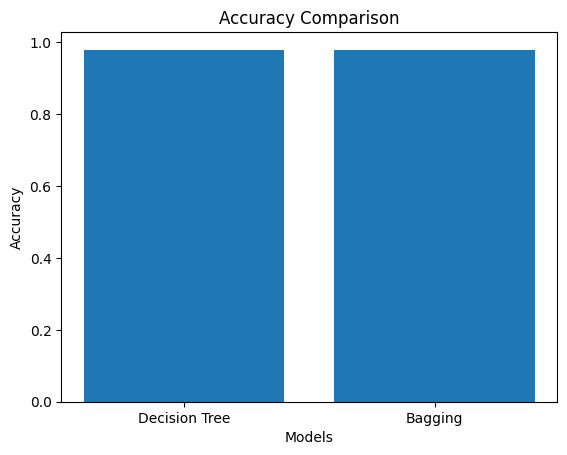

In [16]:
plt.figure()
plt.bar(models, accuracies)
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.show()


Confusion Matrix (Bagging Model)

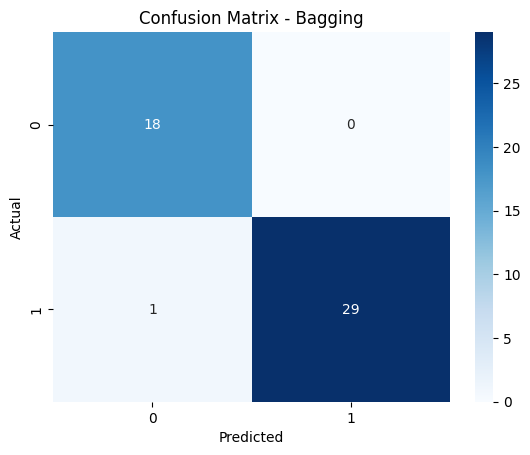

In [17]:
cm = confusion_matrix(y_test, y_pred_bag)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Bagging")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()